# DTL, Logistic Regression, SVM - Loan Approval Classification
From-scratch implementations vs scikit-learn, 5-fold CV, dan generate submission.csv.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join("..", "..", "src", "dtl_lr_svm")))

import numpy as np
import pandas as pd

from data import prepare_train_test, to_xy, fit_standardizer, standardize, k_fold_indices, TARGET, ID_COL
from metrics import macro_f1, accuracy
from algoritma.decision_tree import DecisionTreeCARTScratch
from algoritma.logistic_regression import LogisticRegressionScratch
from algoritma.svm import LinearSVMScratch

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

SEED = 42
N_FOLDS = 5

train_df, test_df, cols = prepare_train_test("../../data")
X_all, y_all = to_xy(train_df, cols)
X_test, _ = to_xy(test_df, cols)
print(f"Train: {X_all.shape}, Test: {X_test.shape}")
print(f"Fitur ({len(cols)}): {cols}")
train_df.head()

Train: (28800, 14), Test: (7200, 14)
Fitur (14): ['person_age', 'person_gender', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT']


,person_id,person_age,person_gender,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT
0,5806,24.0,0,10.256676,1,8.612685,6.54,0.19,3.0,683,1,0,0,0,0,1
1,36976,28.0,1,11.419076,3,8.294300,12.85,0.04,4.0,579,1,0,0,0,0,1
2,19739,28.0,0,10.342258,6,8.160804,7.14,0.11,10.0,627,1,0,0,0,0,1
3,29125,45.0,1,11.481693,25,10.463132,11.01,0.36,13.0,566,0,1,0,0,0,1
4,31212,39.0,1,10.794871,21,9.392745,10.74,0.25,16.0,638,0,0,0,0,0,1


## EDA Singkat

Temuan kunci: `previous_loan_defaults_on_file = Yes` berkorelasi sempurna dengan `loan_status = 0` (ditolak).

In [2]:
raw_train = pd.read_csv("../../data/train.csv")
print(raw_train["loan_status"].value_counts(normalize=True))
print()
print(pd.crosstab(raw_train.previous_loan_defaults_on_file, raw_train.loan_status, normalize="index"))
print()
print("Outlier: person_age > 100 ->", (raw_train.person_age > 100).sum(), "baris")
print("Outlier: person_emp_exp > 60 ->", (raw_train.person_emp_exp > 60).sum(), "baris")

loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64

loan_status                            0         1
previous_loan_defaults_on_file                    
No                              0.548373  0.451627
Yes                             1.000000  0.000000

Outlier: person_age > 100 -> 4 baris
Outlier: person_emp_exp > 60 -> 7 baris


## Cross-Validation: DTL (CART) from scratch vs scikit-learn

Ukuran tree dikendalikan lewat **cost-complexity post-pruning** (`ccp_alpha`), bukan lewat batas
kedalaman. Alasannya: pre-pruning harus memutuskan berhenti *sebelum* tahu apakah subtree di
bawahnya berguna, sementara pruning menumbuhkan tree besar dulu lalu membuang subtree yang tidak
sepadan dengan tambahan leaf-nya. Sel berikutnya membandingkan keduanya secara langsung.

Catatan: class-balanced sample weighting sempat dicoba tapi terbukti menurunkan macro F1
(lihat write-up bagian "Percobaan yang Gagal"), sehingga `sample_weight=None` di sini.

In [3]:
def cross_validate(name, fit_predict_fn, X, y, k=N_FOLDS):
    scores = []
    for fold, (tr_idx, va_idx) in enumerate(k_fold_indices(len(y), k, seed=SEED)):
        pred = fit_predict_fn(X[tr_idx], y[tr_idx], X[va_idx])
        scores.append(macro_f1(y[va_idx], pred))
    print(f"[{name}] CV macro_f1 = {np.mean(scores):.4f} +/- {np.std(scores):.4f}")
    return scores

# Tumbuhkan besar, lalu pangkas. alpha dipilih lewat sweep CV di improve_experiments.py.
TREE_PARAMS = dict(max_depth=16, min_samples_split=10, min_samples_leaf=5, ccp_alpha=3e-4)

def dtl_scratch_fit_predict(Xtr, ytr, Xva):
    model = DecisionTreeCARTScratch(**TREE_PARAMS)
    model.fit(Xtr, ytr, sample_weight=None)
    return model.predict(Xva)

def dtl_sklearn_fit_predict(Xtr, ytr, Xva):
    model = DecisionTreeClassifier(**TREE_PARAMS, random_state=SEED)
    model.fit(Xtr, ytr)
    return model.predict(Xva)

dtl_scratch_scores = cross_validate("DTL-scratch", dtl_scratch_fit_predict, X_all, y_all)
dtl_sklearn_scores = cross_validate("DTL-sklearn", dtl_sklearn_fit_predict, X_all, y_all)

# Perbandingan langsung: pre-pruning (setelan awal) vs post-pruning.
def dtl_prepruned(Xtr, ytr, Xva):
    model = DecisionTreeCARTScratch(max_depth=8, min_samples_split=40, min_samples_leaf=20)
    model.fit(Xtr, ytr, sample_weight=None)
    return model.predict(Xva)

_ = cross_validate("DTL-pre-pruning (pembanding)", dtl_prepruned, X_all, y_all)

tree = DecisionTreeCARTScratch(**TREE_PARAMS).fit(X_all, y_all)
print(f"\nTree hasil pruning: {tree.n_leaves()} leaf, depth {tree.depth()}")

[DTL-scratch] CV macro_f1 = 0.8747 +/- 0.0082


[DTL-sklearn] CV macro_f1 = 0.8745 +/- 0.0083


[DTL-pre-pruning (pembanding)] CV macro_f1 = 0.8701 +/- 0.0082



Tree hasil pruning: 34 leaf, depth 13


## Cross-Validation: Logistic Regression from scratch vs scikit-learn

In [4]:
def lr_scratch_fit_predict(Xtr, ytr, Xva):
    mean, std = fit_standardizer(Xtr)
    Xtr_s, Xva_s = standardize(Xtr, mean, std), standardize(Xva, mean, std)
    model = LogisticRegressionScratch(lr=0.5, n_epochs=800, l2=1e-3)
    model.fit(Xtr_s, ytr, sample_weight=None)
    return model.predict(Xva_s)

def lr_sklearn_fit_predict(Xtr, ytr, Xva):
    mean, std = fit_standardizer(Xtr)
    Xtr_s, Xva_s = standardize(Xtr, mean, std), standardize(Xva, mean, std)
    model = LogisticRegression(max_iter=1000, C=1.0 / (2 * 1e-3))
    model.fit(Xtr_s, ytr)
    return model.predict(Xva_s)

lr_scratch_scores = cross_validate("LR-scratch", lr_scratch_fit_predict, X_all, y_all)
lr_sklearn_scores = cross_validate("LR-sklearn", lr_sklearn_fit_predict, X_all, y_all)

[LR-scratch] CV macro_f1 = 0.8466 +/- 0.0090
[LR-sklearn] CV macro_f1 = 0.8467 +/- 0.0091


## Cross-Validation: SVM (Pegasos) from scratch vs scikit-learn

In [5]:
def svm_scratch_fit_predict(Xtr, ytr, Xva):
    mean, std = fit_standardizer(Xtr)
    Xtr_s, Xva_s = standardize(Xtr, mean, std), standardize(Xva, mean, std)
    model = LinearSVMScratch(lam=1e-3, n_epochs=15, batch_size=256, seed=SEED)
    model.fit(Xtr_s, ytr, sample_weight=None)
    return model.predict(Xva_s)

def svm_sklearn_fit_predict(Xtr, ytr, Xva):
    mean, std = fit_standardizer(Xtr)
    Xtr_s, Xva_s = standardize(Xtr, mean, std), standardize(Xva, mean, std)
    model = LinearSVC(max_iter=5000, C=1.0)
    model.fit(Xtr_s, ytr)
    return model.predict(Xva_s)

svm_scratch_scores = cross_validate("SVM-scratch", svm_scratch_fit_predict, X_all, y_all)
svm_sklearn_scores = cross_validate("SVM-sklearn", svm_sklearn_fit_predict, X_all, y_all)

[SVM-scratch] CV macro_f1 = 0.8456 +/- 0.0087


[SVM-sklearn] CV macro_f1 = 0.8470 +/- 0.0092


## Ringkasan & Generate Kaggle Submission

In [6]:
summary = pd.DataFrame({
    "model": ["DTL-scratch", "DTL-sklearn", "LR-scratch", "LR-sklearn", "SVM-scratch", "SVM-sklearn"],
    "mean_macro_f1": [np.mean(s) for s in (dtl_scratch_scores, dtl_sklearn_scores,
                                             lr_scratch_scores, lr_sklearn_scores,
                                             svm_scratch_scores, svm_sklearn_scores)],
    "std_macro_f1": [np.std(s) for s in (dtl_scratch_scores, dtl_sklearn_scores,
                                           lr_scratch_scores, lr_sklearn_scores,
                                           svm_scratch_scores, svm_sklearn_scores)],
})
display(summary)

# Model from-scratch terbaik -> latih ulang di seluruh data latih -> submission Kaggle
best_name = summary.loc[summary["model"].str.endswith("scratch"), :] \
    .sort_values("mean_macro_f1", ascending=False).iloc[0]["model"]
print(f"Model from-scratch terbaik: {best_name}")

if best_name == "DTL-scratch":
    final_model = DecisionTreeCARTScratch(**TREE_PARAMS)
    final_model.fit(X_all, y_all, sample_weight=None)
    test_pred = final_model.predict(X_test)
else:
    mean, std = fit_standardizer(X_all)
    X_all_s, X_test_s = standardize(X_all, mean, std), standardize(X_test, mean, std)
    if best_name == "LR-scratch":
        final_model = LogisticRegressionScratch(lr=0.5, n_epochs=800, l2=1e-3)
    else:
        final_model = LinearSVMScratch(lam=1e-3, n_epochs=15, batch_size=256, seed=SEED)
    final_model.fit(X_all_s, y_all, sample_weight=None)
    test_pred = final_model.predict(X_test_s)

submission = pd.DataFrame({ID_COL: test_df[ID_COL].values, TARGET: test_pred.astype(int)})
submission.to_csv("../../src/dtl_lr_svm/result/submission.csv", index=False)
print(submission[TARGET].value_counts())
submission.head()

,model,mean_macro_f1,std_macro_f1
0,DTL-scratch,0.874686,0.008213
1,DTL-sklearn,0.874469,0.008275
2,LR-scratch,0.846614,0.009029
3,LR-sklearn,0.846726,0.009050
4,SVM-scratch,0.845602,0.008748
5,SVM-sklearn,0.847020,0.009194


Model from-scratch terbaik: DTL-scratch


loan_status
0    5782
1    1418
Name: count, dtype: int64


,person_id,loan_status
0,8121,0
1,22683,0
2,17123,0
3,33342,0
4,35053,0


## Bonus: Visualisasi Tree & Training LR

Lihat `src/dtl_lr_svm/bonus_visualizations.py` untuk kode lengkap. Gambar disimpan di
`src/dtl_lr_svm/pic/`.

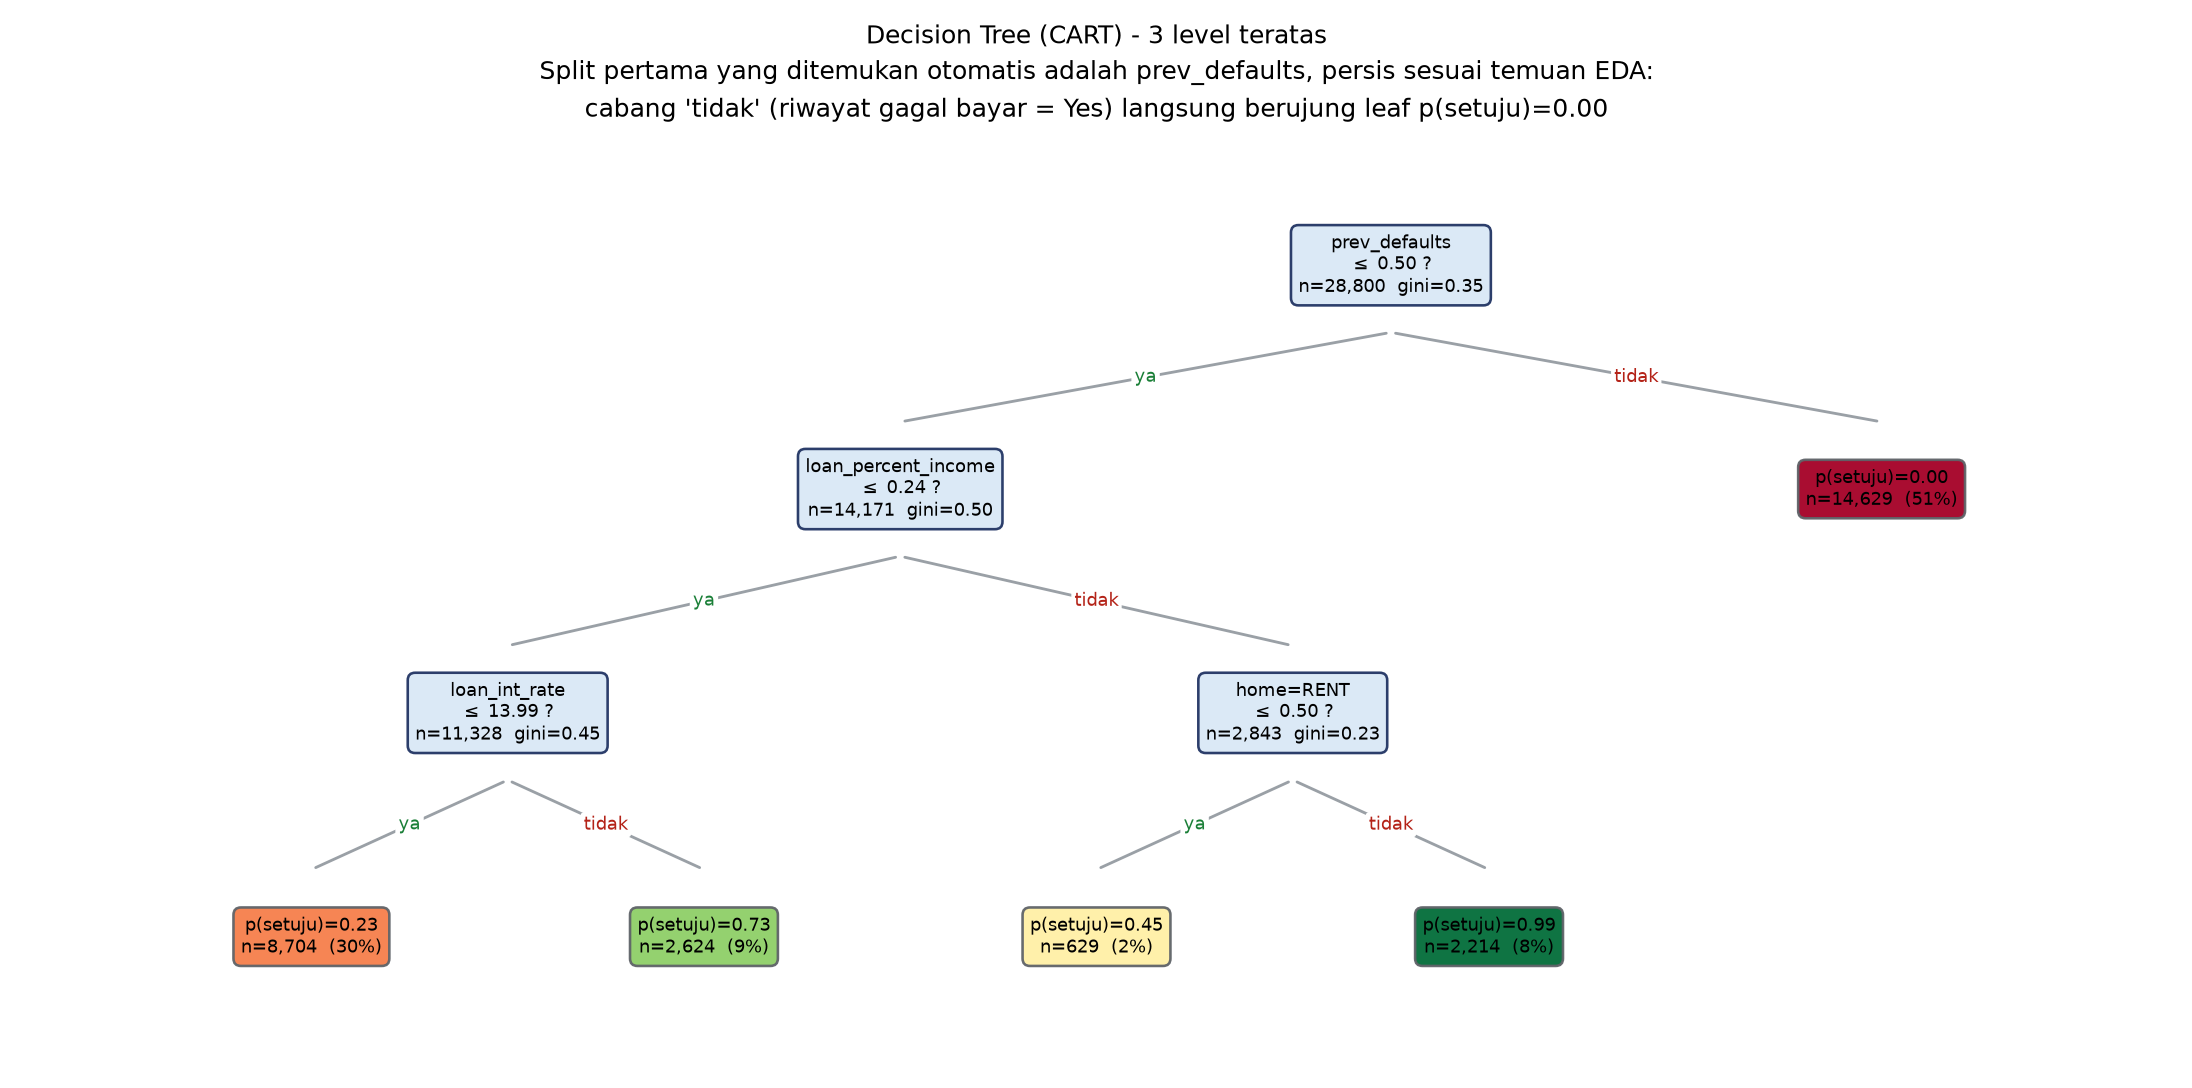

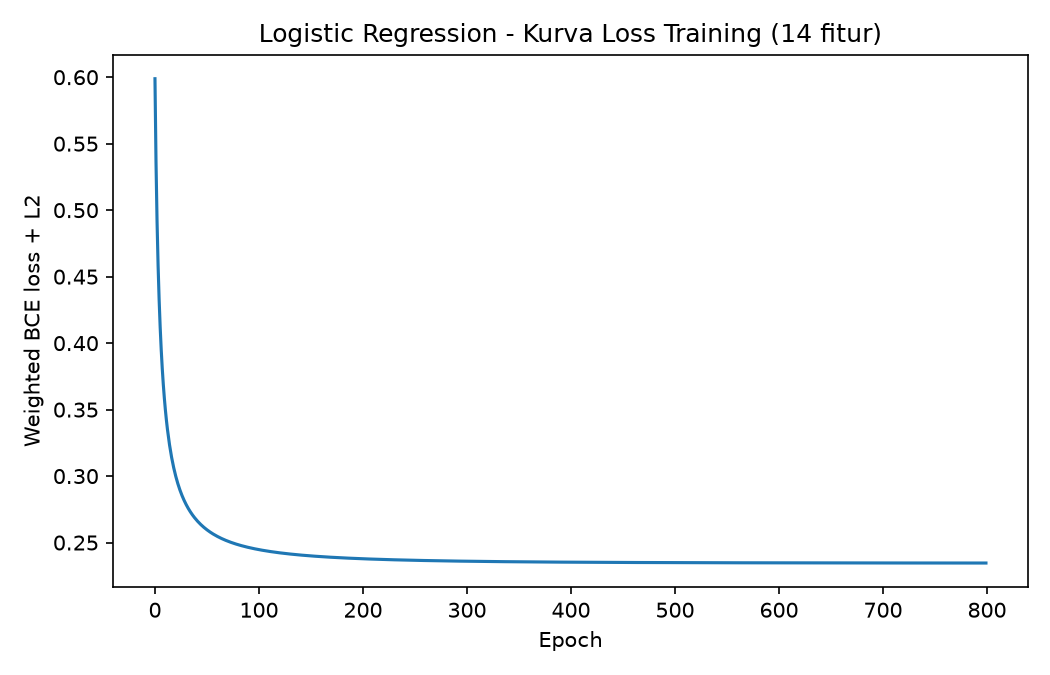

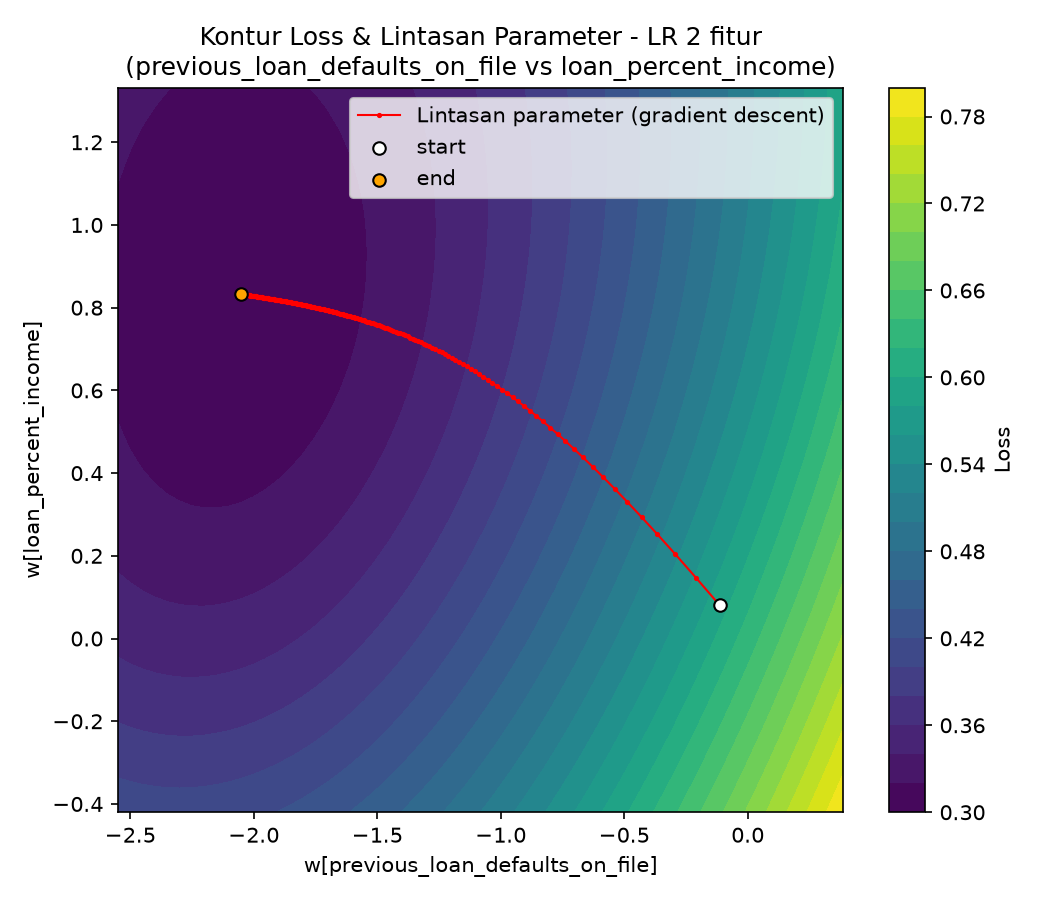

In [7]:
from IPython.display import Image, display as ipy_display

for img in ["tree_plot.png", "lr_loss_curve.png", "lr_loss_contour.png"]:
    path = os.path.join("..", "..", "src", "dtl_lr_svm", "pic", img)
    if os.path.exists(path):
        ipy_display(Image(filename=path))
    else:
        print(f"{img} belum digenerate - jalankan bonus_visualizations.py terlebih dahulu.")